# UTS Pembelajaran Mesin — Klasifikasi Kanker Payudara (WDBC)
**Nama:** Nayyara Rauf Ghani Al Khayri
**NIM:** A11.2024.16055
**Kelas:** A11.4410
**Mata Kuliah:** Pembelajaran Mesin
**Dosen:** Junta Zeniarja, M.Kom
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) — UCI Machine Learning Repository

---

## SOAL 01 — Konsep Dasar Pembelajaran Mesin & Problem Framing

### 1.1 Pengertian Pembelajaran Mesin

Pembelajaran mesin (*machine learning*) adalah cabang kecerdasan buatan yang memungkinkan sistem komputer belajar dari data tanpa diprogram secara eksplisit untuk setiap tugas. Sistem mempelajari pola dari data historis untuk membuat prediksi atau keputusan pada data baru.

Terdapat tiga paradigma utama:

| Paradigma | Deskripsi | Contoh Kasus |
|---|---|---|
| **Supervised Learning** | Dilatih menggunakan data berlabel (pasangan input–output). Sistem mempelajari fungsi pemetaan dari input ke output. | Klasifikasi tumor (jinak/ganas), deteksi spam |
| **Unsupervised Learning** | Bekerja pada data tanpa label. Tujuannya menemukan struktur atau pola tersembunyi. | Clustering pelanggan, reduksi dimensi PCA |
| **Semi-supervised Learning** | Kombinasi sedikit data berlabel dan banyak data tidak berlabel. Memanfaatkan struktur data tidak berlabel untuk meningkatkan performa. | Klasifikasi teks dengan sedikit anotasi |

### 1.2 Alasan Ilmiah: Mengapa Ini Permasalahan Klasifikasi

Kasus yang dipilih — deteksi kanker payudara berdasarkan pengukuran sel tumor — merupakan **klasifikasi biner**, bukan regresi maupun klastering, karena:

1. **Target bersifat kategoris diskrit:** Variabel `diagnosis` hanya memiliki dua nilai — *Malignant* (ganas) dan *Benign* (jinak). Tidak ada nilai kontinu atau urutan ordinal yang bermakna di antara keduanya.
2. **Pertanyaan prediksinya adalah label kelas:** "Apakah tumor ini ganas atau jinak?" — bukan "Seberapa besar tumor ini?" (regresi) atau "Kelompok mana tumor ini termasuk?" (klastering tanpa label).
3. **Label tersedia dari hasil biopsi:** Data sudah memiliki ground truth dari diagnosis medis, sehingga klastering tidak diperlukan.

### 1.3 Identifikasi Fitur, Target, dan Tantangan Data

**Sumber:** UCI Machine Learning Repository — Wisconsin Diagnostic Breast Cancer (WDBC)
**Jumlah sampel:** 569 baris | **Fitur prediktor:** 30 fitur numerik kontinu | **Target:** `diagnosis`

Ke-30 fitur merupakan pengukuran inti sel tumor (*radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension*) dalam tiga dimensi statistik: *mean*, *standard error*, dan *worst*.

**Potensi tantangan data:**

| Tantangan | Kondisi pada WDBC | Strategi yang Dipilih |
|---|---|---|
| Missing value | Tidak ada | Tidak diperlukan imputasi |
| Data duplikat | Tidak ada | Tidak diperlukan penghapusan |
| Outlier | Ada pada beberapa fitur (IQR) | Dipertahankan — data medis nyata, nilai ekstrem bisa bermakna klinis |
| Class imbalance | 357 Benign (62.7%) vs 212 Malignant (37.3%) | Gunakan `stratify=y` pada split data |
| Multikolinearitas | Korelasi tinggi (>0.9) antar fitur | Seleksi fitur berbasis korelasi |
| Skala fitur berbeda | Area (~1000) vs fractal dimension (~0.06) | StandardScaler untuk KNN & Naive Bayes |

---

## 1. Import Library

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
import joblib
import os

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Library berhasil diimpor.")

Library berhasil diimpor.


---
## SOAL 02 — Audit Dataset & Data Preprocessing

### 2.1 Load Dataset

In [26]:
df = pd.read_csv("../data/wdbc.csv", header=None)

columns = ["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
df.columns = columns

print(f"Dataset berhasil dimuat.")
print(f"Jumlah baris  : {df.shape[0]}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()

Dataset berhasil dimuat.
Jumlah baris  : 569
Jumlah kolom  : 32


,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.2 Audit Data

In [27]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          569 non-null    int64  
 1   diagnosis   569 non-null    str    
 2   feature_1   569 non-null    float64
 3   feature_2   569 non-null    float64
 4   feature_3   569 non-null    float64
 5   feature_4   569 non-null    float64
 6   feature_5   569 non-null    float64
 7   feature_6   569 non-null    float64
 8   feature_7   569 non-null    float64
 9   feature_8   569 non-null    float64
 10  feature_9   569 non-null    float64
 11  feature_10  569 non-null    float64
 12  feature_11  569 non-null    float64
 13  feature_12  569 non-null    float64
 14  feature_13  569 non-null    float64
 15  feature_14  569 non-null    float64
 16  feature_15  569 non-null    float64
 17  feature_16  569 non-null    float64
 18  feature_17  569 non-null    float64
 19  feature_18  569 non-null    float64
 20 

,id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [28]:
# ── Audit: missing values, duplikat, distribusi kelas ───────
print("=" * 50)
print("HASIL AUDIT DATA")
print("=" * 50)

missing  = df.isnull().sum().sum()
duplikat = df.duplicated().sum()
kelas    = df["diagnosis"].value_counts()
rasio    = df["diagnosis"].value_counts(normalize=True) * 100

print(f"Missing values    : {missing}")
print(f"Data duplikat     : {duplikat}")
print(f"Jumlah kelas      : {df['diagnosis'].nunique()} (B=Benign, M=Malignant)")
print()
print("Distribusi kelas:")
for k in kelas.index:
    print(f"  {k}: {kelas[k]} sampel ({rasio[k]:.1f}%)")
print()
print("Kesimpulan: Tidak ada missing value atau duplikat.")
print("Terdapat class imbalance ringan (62.7% vs 37.3%).")
print("Strategi: gunakan stratify=y pada train_test_split.")

HASIL AUDIT DATA
Missing values    : 0
Data duplikat     : 0
Jumlah kelas      : 2 (B=Benign, M=Malignant)

Distribusi kelas:
  B: 357 sampel (62.7%)
  M: 212 sampel (37.3%)

Kesimpulan: Tidak ada missing value atau duplikat.
Terdapat class imbalance ringan (62.7% vs 37.3%).
Strategi: gunakan stratify=y pada train_test_split.


### 2.3 Distribusi Kelas

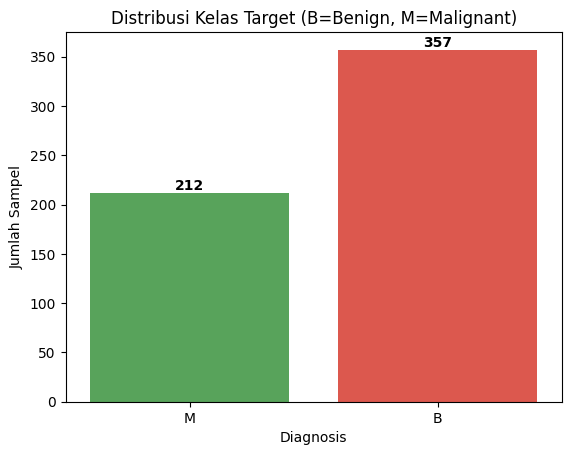

In [29]:
sns.countplot(x=df["diagnosis"], palette=["#4CAF50", "#F44336"])
plt.title("Distribusi Kelas Target (B=Benign, M=Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Jumlah Sampel")
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height())}",
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha="center", va="bottom", fontweight="bold")
plt.show()

### 2.4 Analisis Outlier (Metode IQR)

In [30]:
X_raw = df.drop(columns=["id", "diagnosis"])

Q1  = X_raw.quantile(0.25)
Q3  = X_raw.quantile(0.75)
IQR = Q3 - Q1

outlier_mask  = (X_raw < (Q1 - 1.5*IQR)) | (X_raw > (Q3 + 1.5*IQR))
outlier_count = outlier_mask.sum().sort_values(ascending=False)

print("=" * 50)
print("ANALISIS OUTLIER (Metode IQR)")
print("=" * 50)
print(f"Total sel outlier : {outlier_mask.sum().sum()}")
print()
print("10 fitur dengan outlier terbanyak:")
print(outlier_count.head(10).to_string())
print()
print("Keputusan: Outlier DIPERTAHANKAN.")
print("Alasan   : Data medis nyata — nilai ekstrem pada")
print("           pengukuran sel tumor bisa bermakna klinis.")
print("           Sel kanker ganas memang cenderung memiliki")
print("           ukuran dan bentuk yang tidak normal (ekstrem).")

ANALISIS OUTLIER (Metode IQR)
Total sel outlier : 608

10 fitur dengan outlier terbanyak:
feature_14    65
feature_11    38
feature_13    38
feature_24    35
feature_15    30
feature_20    28
feature_16    28
feature_19    27
feature_4     25
feature_30    24

Keputusan: Outlier DIPERTAHANKAN.
Alasan   : Data medis nyata — nilai ekstrem pada
           pengukuran sel tumor bisa bermakna klinis.
           Sel kanker ganas memang cenderung memiliki
           ukuran dan bentuk yang tidak normal (ekstrem).


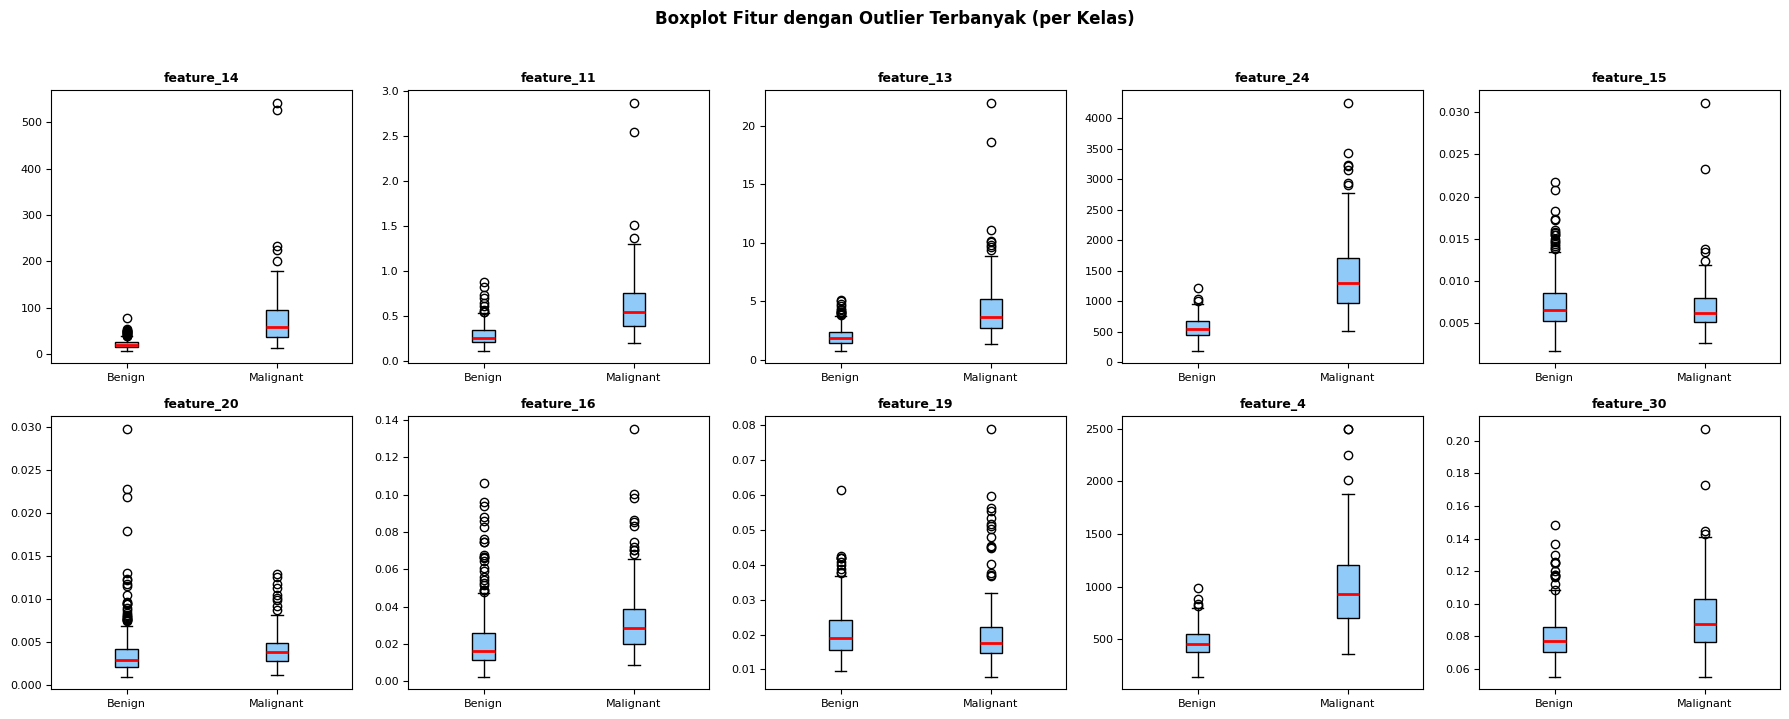

In [ ]:
tebook nya supaya sesuai dengan laporan terakhir yang kamu buat!# Boxplot 10 fitur dengan outlier terbanyak
top_outlier_features = outlier_count.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, feat in enumerate(top_outlier_features):
    ax = axes[i//5][i%5]
    data_B = X_raw.loc[df["diagnosis"]=="B", feat]
    data_M = X_raw.loc[df["diagnosis"]=="M", feat]
    ax.boxplot([data_B, data_M], labels=["Benign","Malignant"],
               patch_artist=True,
               boxprops=dict(facecolor="#90CAF9"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=8)

plt.suptitle("Boxplot Fitur dengan Outlier Terbanyak (per Kelas)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Preprocessing

In [32]:
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("Preprocessing dasar selesai:")
print(f"  Drop kolom ID      : ✓")
print(f"  Encode target      : B→0, M→1")
print(f"  Shape X            : {X.shape}")
print(f"  Shape y            : {y.shape}")

Preprocessing dasar selesai:
  Drop kolom ID      : ✓
  Encode target      : B→0, M→1
  Shape X            : (569, 30)
  Shape y            : (569,)


---
## SOAL 03 — Seleksi Atribut, Split Data, dan Desain Eksperimen

### 3.1 Seleksi Fitur Berbasis Korelasi

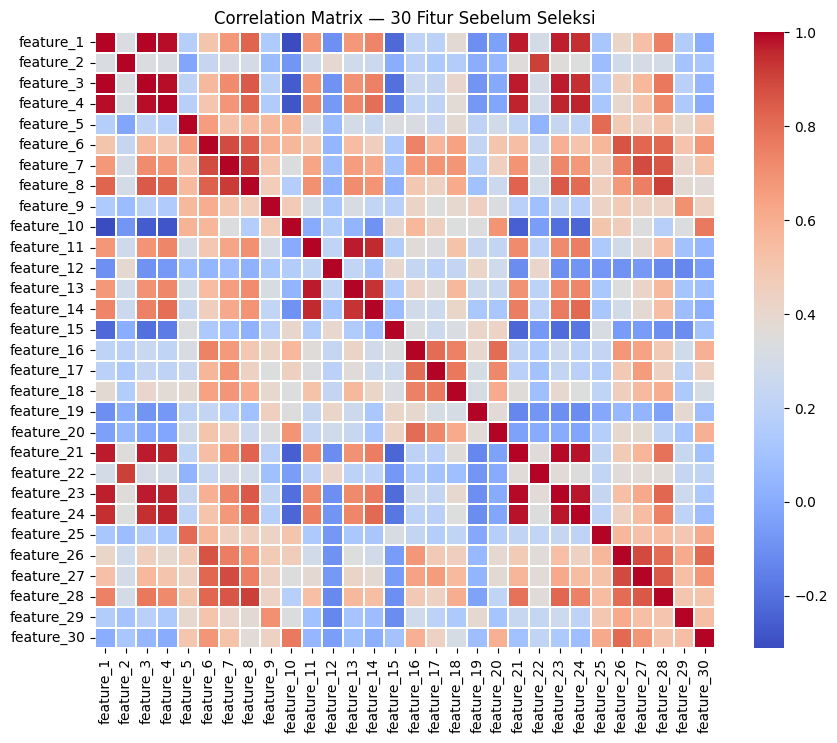

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm", linewidths=0.1)
plt.title("Correlation Matrix — 30 Fitur Sebelum Seleksi")
plt.show()

In [34]:
# Seleksi fitur: hapus fitur dengan korelasi > 0.9 (redundan)
corr_matrix   = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.9)]

print("=" * 55)
print("SELEKSI FITUR — Korelasi Threshold > 0.9")
print("=" * 55)
print(f"Fitur yang dibuang ({len(to_drop)} fitur):")
for f in to_drop:
    print(f"  - {f}")
print()
print(f"Jumlah fitur sebelum seleksi : {X.shape[1]}")

X_selected = X.drop(columns=to_drop)
print(f"Jumlah fitur sesudah seleksi : {X_selected.shape[1]}")
print()
print("Alasan: Fitur yang berkorelasi sangat tinggi (>0.9)")
print("memberikan informasi redundan. Membuangnya mengurangi")
print("multikolinearitas, mempercepat komputasi KNN, dan")
print("meningkatkan stabilitas model Naive Bayes.")

SELEKSI FITUR — Korelasi Threshold > 0.9
Fitur yang dibuang (10 fitur):
  - feature_3
  - feature_4
  - feature_8
  - feature_13
  - feature_14
  - feature_21
  - feature_22
  - feature_23
  - feature_24
  - feature_28

Jumlah fitur sebelum seleksi : 30
Jumlah fitur sesudah seleksi : 20

Alasan: Fitur yang berkorelasi sangat tinggi (>0.9)
memberikan informasi redundan. Membuangnya mengurangi
multikolinearitas, mempercepat komputasi KNN, dan
meningkatkan stabilitas model Naive Bayes.


### 3.2 Strategi Split Data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Strategi: Train-Test Split 80:20 dengan Stratified Sampling")
print()
print(f"Training set : {X_train.shape[0]} sampel")
print(f"Test set     : {X_test.shape[0]} sampel")
print()
print("Distribusi kelas training :")
print(f"  Benign   : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Malignant: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print()
print("Distribusi kelas test:")
print(f"  Benign   : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Malignant: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")
print()
print("Alasan 80:20: Dataset 569 sampel — training 455 sampel")
print("cukup representatif. stratify=y menjaga proporsi kelas.")

Strategi: Train-Test Split 80:20 dengan Stratified Sampling

Training set : 455 sampel
Test set     : 114 sampel

Distribusi kelas training :
  Benign   : 285 (62.6%)
  Malignant: 170 (37.4%)

Distribusi kelas test:
  Benign   : 72 (63.2%)
  Malignant: 42 (36.8%)

Alasan 80:20: Dataset 569 sampel — training 455 sampel
cukup representatif. stratify=y menjaga proporsi kelas.


### 3.3 Feature Scaling

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler diterapkan.")
print()
print("Catatan penting:")
print("  Scaler di-fit HANYA pada X_train → mencegah data leakage")
print("  KNN & Naive Bayes : gunakan X_train_scaled / X_test_scaled")
print("  Decision Tree     : gunakan X_train / X_test")
print("  (DT tidak sensitif terhadap skala — bekerja berbasis threshold)")

StandardScaler diterapkan.

Catatan penting:
  Scaler di-fit HANYA pada X_train → mencegah data leakage
  KNN & Naive Bayes : gunakan X_train_scaled / X_test_scaled
  Decision Tree     : gunakan X_train / X_test
  (DT tidak sensitif terhadap skala — bekerja berbasis threshold)


### 3.4 Rancangan Eksperimen & Baseline

In [37]:
# Baseline model — prediksi selalu kelas mayoritas
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
acc_base = accuracy_score(y_test, baseline.predict(X_test_scaled))

print("=" * 60)
print("RANCANGAN EKSPERIMEN")
print("=" * 60)

rancangan = {
    "Model"          : ["Baseline (Dummy)", "KNN","KNN","KNN","KNN",
                        "Decision Tree","Decision Tree","Naive Bayes"],
    "Parameter"      : ["most_frequent","k=3","k=5","k=7","k=9",
                        "max_depth=3","max_depth=5","GaussianNB"],
    "Data"           : ["X_test_scaled","X_test_scaled","X_test_scaled",
                        "X_test_scaled","X_test_scaled",
                        "X_test (no scale)","X_test (no scale)","X_test_scaled"],
    "Hipotesis"      : ["~63%","~90%","~94%","~92%","~93%",
                        "~90%","~93%","~89%"]
}
import pandas as pd
print(pd.DataFrame(rancangan).to_string(index=False))
print()
print(f"Baseline accuracy : {acc_base:.4f} ({acc_base*100:.2f}%)")
print("Kriteria terbaik  : F1-Score kelas Malignant (minimasi FN)")
print()
print("Kesesuaian algoritma dengan WDBC:")
print("  KNN          : Semua fitur numerik kontinu → jarak Euclidean bermakna")
print("  Decision Tree: Tidak sensitif skala; hasil mudah diinterpretasi dokter")
print("  Naive Bayes  : GaussianNB cocok untuk fitur kontinu")

RANCANGAN EKSPERIMEN
           Model     Parameter              Data Hipotesis
Baseline (Dummy) most_frequent     X_test_scaled      ~63%
             KNN           k=3     X_test_scaled      ~90%
             KNN           k=5     X_test_scaled      ~94%
             KNN           k=7     X_test_scaled      ~92%
             KNN           k=9     X_test_scaled      ~93%
   Decision Tree   max_depth=3 X_test (no scale)      ~90%
   Decision Tree   max_depth=5 X_test (no scale)      ~93%
     Naive Bayes    GaussianNB     X_test_scaled      ~89%

Baseline accuracy : 0.6316 (63.16%)
Kriteria terbaik  : F1-Score kelas Malignant (minimasi FN)

Kesesuaian algoritma dengan WDBC:
  KNN          : Semua fitur numerik kontinu → jarak Euclidean bermakna
  Decision Tree: Tidak sensitif skala; hasil mudah diinterpretasi dokter
  Naive Bayes  : GaussianNB cocok untuk fitur kontinu


---
## SOAL 04 — Implementasi dan Perbandingan Algoritma Klasifikasi

### 4.1 Training KNN

In [38]:
k_values   = [3, 5, 7, 9, 11]
best_knn   = None
best_score = 0
best_k     = None
knn_times  = []

print("Training KNN — Tuning nilai k:")
print("-" * 40)

t_total = time.time()
for k in k_values:
    t0    = time.time()
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred  = model.predict(X_test_scaled)
    acc   = accuracy_score(y_test, pred)
    f1    = f1_score(y_test, pred, zero_division=0)
    elapsed = time.time() - t0
    knn_times.append(elapsed)

    print(f"  k={k:>2} → Accuracy={acc:.4f}, F1-Malignant={f1:.4f}, waktu={elapsed:.4f}s")

    if acc > best_score:
        best_score = acc
        best_knn   = model
        best_k     = k

t_knn = time.time() - t_total
print(f"\nModel terbaik: k={best_k}")
print(f"Accuracy     : {best_score:.4f}")
print(f"Waktu total  : {t_knn:.3f} detik")
print()
print("Catatan: KNN memerlukan StandardScaler karena bekerja")
print("berdasarkan jarak Euclidean. Fitur berskala besar akan")
print("mendominasi perhitungan jarak jika tidak dinormalisasi.")

Training KNN — Tuning nilai k:
----------------------------------------
  k= 3 → Accuracy=0.9298, F1-Malignant=0.9000, waktu=0.0503s
  k= 5 → Accuracy=0.9474, F1-Malignant=0.9250, waktu=0.0233s
  k= 7 → Accuracy=0.9211, F1-Malignant=0.8861, waktu=0.0258s


  k= 9 → Accuracy=0.9386, F1-Malignant=0.9136, waktu=0.0349s
  k=11 → Accuracy=0.9298, F1-Malignant=0.9000, waktu=0.0162s

Model terbaik: k=5
Accuracy     : 0.9474
Waktu total  : 0.153 detik

Catatan: KNN memerlukan StandardScaler karena bekerja
berdasarkan jarak Euclidean. Fitur berskala besar akan
mendominasi perhitungan jarak jika tidak dinormalisasi.


### 4.2 Training Decision Tree

In [39]:
print("Training Decision Tree — 5-Fold Cross Validation")
print("-" * 50)
print("Catatan: Decision Tree TIDAK memerlukan scaling.")
print("DT bekerja berdasarkan threshold nilai fitur (bukan jarak),")
print("sehingga skala tidak mempengaruhi hasil split.")
print()

param_grid = [
    {"max_depth": 3, "min_samples_split": 10, "min_samples_leaf": 5},
    {"max_depth": 5, "min_samples_split": 10, "min_samples_leaf": 5},
    {"max_depth": 5, "min_samples_split":  5, "min_samples_leaf": 3},
    {"max_depth": 7, "min_samples_split":  5, "min_samples_leaf": 2},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_dt_params, best_dt_cv = None, 0

print(f"  {'max_depth':>9}  {'CV Mean':>8}  {'CV Std':>7}")
print(f"  {'-'*9}  {'-'*8}  {'-'*7}")

t0 = time.time()
for params in param_grid:
    model  = DecisionTreeClassifier(**params, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"  depth={str(params['max_depth']):>4}     {scores.mean():.4f}    ±{scores.std():.4f}")
    if scores.mean() > best_dt_cv:
        best_dt_cv, best_dt_params = scores.mean(), params

# Retrain pada seluruh training set
dt = DecisionTreeClassifier(**best_dt_params, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
t_dt = time.time() - t0

print(f"\nParameter terbaik: {best_dt_params}")
print(f"CV Accuracy      : {best_dt_cv:.4f}")
print(f"Waktu training   : {t_dt:.3f} detik")
print(f"Kedalaman aktual : {dt.get_depth()}")
print(f"Jumlah leaf node : {dt.get_n_leaves()}")

Training Decision Tree — 5-Fold Cross Validation
--------------------------------------------------
Catatan: Decision Tree TIDAK memerlukan scaling.
DT bekerja berdasarkan threshold nilai fitur (bukan jarak),
sehingga skala tidak mempengaruhi hasil split.

  max_depth   CV Mean   CV Std
  ---------  --------  -------


  depth=   3     0.9231    ±0.0278
  depth=   5     0.9121    ±0.0155
  depth=   5     0.9253    ±0.0176
  depth=   7     0.9143    ±0.0377

Parameter terbaik: {'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 3}
CV Accuracy      : 0.9253
Waktu training   : 0.248 detik
Kedalaman aktual : 5
Jumlah leaf node : 16


### 4.3 Training Naive Bayes

In [40]:
print("Training Naive Bayes — GaussianNB")
print("-" * 40)
print("Catatan: GaussianNB dipilih karena semua fitur WDBC")
print("bersifat kontinu. GaussianNB mengasumsikan distribusi")
print("Gaussian pada setiap fitur per kelas.")
print("MultinomialNB TIDAK digunakan karena tidak mendukung")
print("nilai negatif yang dihasilkan StandardScaler.")
print()

t0 = time.time()
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
t_nb = time.time() - t0

acc_nb_check = accuracy_score(y_test, nb.predict(X_test_scaled))
print(f"Accuracy   : {acc_nb_check:.4f}")
print(f"Waktu train: {t_nb:.4f} detik (model tercepat)")

Training Naive Bayes — GaussianNB
----------------------------------------
Catatan: GaussianNB dipilih karena semua fitur WDBC
bersifat kontinu. GaussianNB mengasumsikan distribusi
Gaussian pada setiap fitur per kelas.
MultinomialNB TIDAK digunakan karena tidak mendukung
nilai negatif yang dihasilkan StandardScaler.

Accuracy   : 0.8947
Waktu train: 0.0025 detik (model tercepat)


### 4.4 Fungsi Evaluasi

In [41]:
def evaluate(model, X_te, y_te, name):
    pred = model.predict(X_te)

    acc  = accuracy_score(y_te, pred)
    prec = precision_score(y_te, pred, zero_division=0)
    rec  = recall_score(y_te, pred, zero_division=0)
    f1   = f1_score(y_te, pred, zero_division=0)
    cm   = confusion_matrix(y_te, pred)

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print()
    print("  Confusion Matrix:")
    tn, fp, fn, tp = cm.ravel()
    print(f"  TN={tn}  FP={fp}")
    print(f"  FN={fn}   TP={tp}")
    print()
    print("  Classification Report:")
    print(classification_report(y_te, pred, target_names=["Benign","Malignant"]))

    fig, ax = plt.subplots(figsize=(4,3))
    ConfusionMatrixDisplay(cm, display_labels=["Benign","Malignant"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

    return acc, prec, rec, f1, cm

### 4.5 Evaluasi Model


  KNN
  Accuracy  : 0.9474
  Precision : 0.9737
  Recall    : 0.8810
  F1-Score  : 0.9250

  Confusion Matrix:
  TN=71  FP=1
  FN=5   TP=37

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



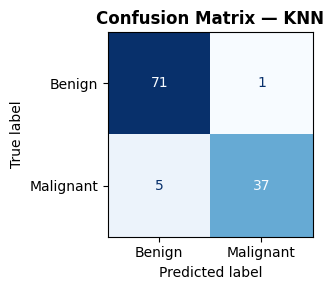


  Decision Tree
  Accuracy  : 0.9035
  Precision : 0.9189
  Recall    : 0.8095
  F1-Score  : 0.8608

  Confusion Matrix:
  TN=69  FP=3
  FN=8   TP=34

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      0.96      0.93        72
   Malignant       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



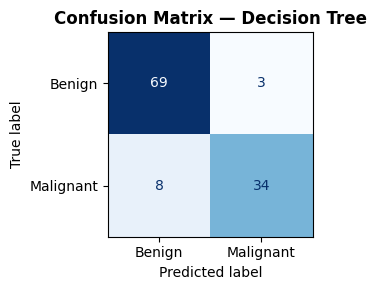


  Naive Bayes
  Accuracy  : 0.8947
  Precision : 0.8947
  Recall    : 0.8095
  F1-Score  : 0.8500

  Confusion Matrix:
  TN=68  FP=4
  FN=8   TP=34

  Classification Report:
              precision    recall  f1-score   support

      Benign       0.89      0.94      0.92        72
   Malignant       0.89      0.81      0.85        42

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



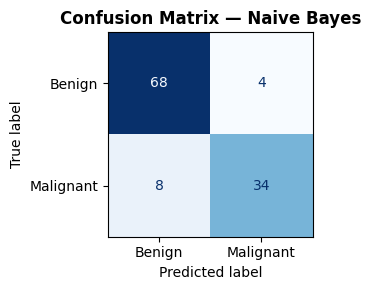

In [42]:
acc_knn, prec_knn, rec_knn, f1_knn, cm_knn = evaluate(best_knn, X_test_scaled, y_test, "KNN")
acc_dt,  prec_dt,  rec_dt,  f1_dt,  cm_dt  = evaluate(dt,       X_test,        y_test, "Decision Tree")
acc_nb,  prec_nb,  rec_nb,  f1_nb,  cm_nb  = evaluate(nb,       X_test_scaled, y_test, "Naive Bayes")

### 4.6 Tabel Perbandingan

In [43]:
results = pd.DataFrame({
    "Model"     : ["KNN", "Decision Tree", "Naive Bayes"],
    "Accuracy"  : [round(acc_knn,4), round(acc_dt,4), round(acc_nb,4)],
    "Precision" : [round(prec_knn,4), round(prec_dt,4), round(prec_nb,4)],
    "Recall"    : [round(rec_knn,4),  round(rec_dt,4),  round(rec_nb,4)],
    "F1-Score"  : [round(f1_knn,4),   round(f1_dt,4),   round(f1_nb,4)],
    "FP"        : [cm_knn.ravel()[1], cm_dt.ravel()[1], cm_nb.ravel()[1]],
    "FN"        : [cm_knn.ravel()[2], cm_dt.ravel()[2], cm_nb.ravel()[2]],
})

print("=" * 65)
print("TABEL KOMPARATIF PERFORMA MODEL")
print("=" * 65)
print(results.to_string(index=False))
print()
print(f"Baseline (Dummy most_frequent): {acc_base:.4f}")
print("Semua model melampaui baseline secara signifikan.")
results

TABEL KOMPARATIF PERFORMA MODEL
        Model  Accuracy  Precision  Recall  F1-Score  FP  FN
          KNN    0.9474     0.9737  0.8810    0.9250   1   5
Decision Tree    0.9035     0.9189  0.8095    0.8608   3   8
  Naive Bayes    0.8947     0.8947  0.8095    0.8500   4   8

Baseline (Dummy most_frequent): 0.6316
Semua model melampaui baseline secara signifikan.


,Model,Accuracy,Precision,Recall,F1-Score,FP,FN
0,KNN,0.9474,0.9737,0.8810,0.9250,1,5
1,Decision Tree,0.9035,0.9189,0.8095,0.8608,3,8
2,Naive Bayes,0.8947,0.8947,0.8095,0.8500,4,8


### 4.7 Visualisasi Perbandingan

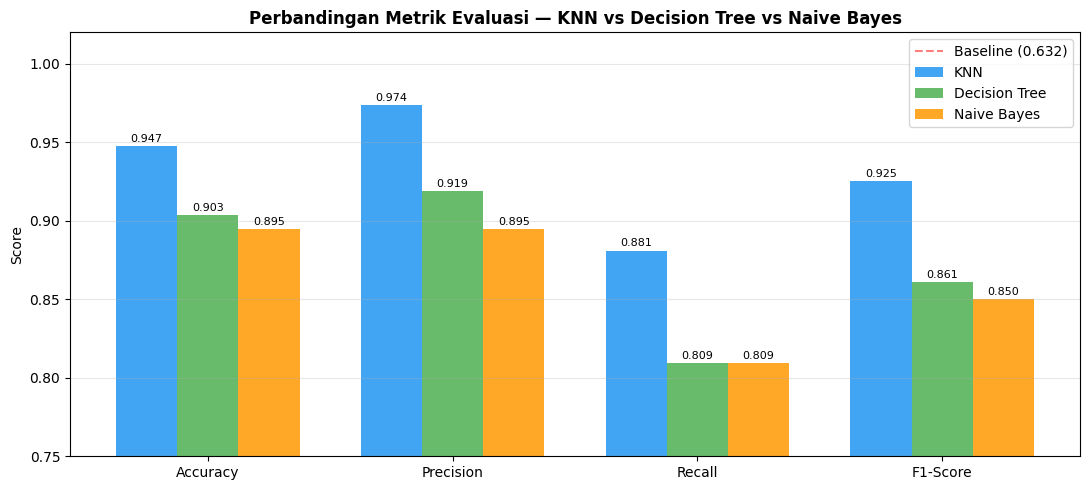

In [44]:
metrics   = ["Accuracy", "Precision", "Recall", "F1-Score"]
x         = np.arange(len(metrics))
width     = 0.25
col_model = ["#2196F3", "#4CAF50", "#FF9800"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, row in results.iterrows():
    vals = [row["Accuracy"], row["Precision"], row["Recall"], row["F1-Score"]]
    bars = ax.bar(x + i*width, vals, width, label=row["Model"],
                  color=col_model[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.annotate(f"{v:.3f}",
                    xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0,3), textcoords="offset points",
                    ha="center", fontsize=8)

ax.axhline(y=acc_base, color="red", linestyle="--", alpha=0.5, label=f"Baseline ({acc_base:.3f})")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel("Score")
ax.set_title("Perbandingan Metrik Evaluasi — KNN vs Decision Tree vs Naive Bayes",
             fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 4.8 Feature Importance & Analisis Algoritma

In [45]:
fs_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
fs_model.fit(X_train, y_train)

importances = fs_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature"   : X_selected.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Top 10 Fitur Paling Penting (berdasarkan Decision Tree):")
print(feature_importance.head(10).to_string(index=False))

Top 10 Fitur Paling Penting (berdasarkan Decision Tree):
   Feature  Importance
 feature_1    0.623136
feature_26    0.132065
 feature_2    0.065677
feature_25    0.052860
feature_11    0.030197
feature_27    0.027756
 feature_7    0.022612
feature_19    0.016155
feature_15    0.009442
 feature_9    0.008361


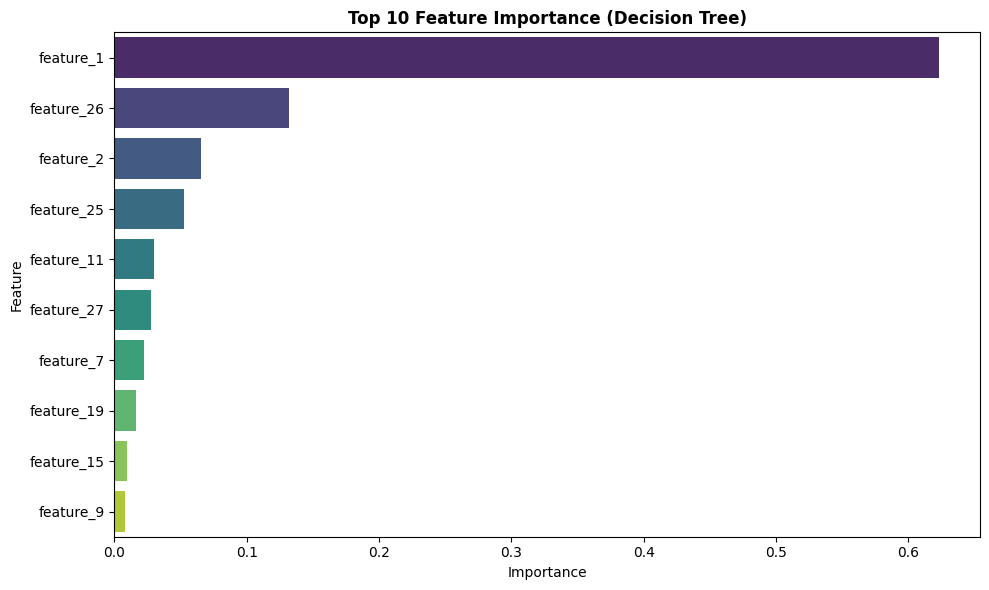

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature",
            data=feature_importance.head(10),
            palette="viridis")
plt.title("Top 10 Feature Importance (Decision Tree)", fontweight="bold")
plt.tight_layout()
plt.show()

In [47]:
print("=" * 60)
print("ANALISIS KEKUATAN & KELEMAHAN TIAP MODEL")
print("=" * 60)

analisis = {
    "KNN": {
        "Kekuatan" : [
            f"Akurasi tertinggi ({acc_knn*100:.2f}%)",
            "Tidak ada asumsi distribusi data",
            f"FN terendah ({cm_knn.ravel()[2]}) — paling aman secara medis"
        ],
        "Kelemahan": [
            "Prediksi lambat: O(n·d) — hitung jarak ke semua training data",
            "Tidak interpretatif — sulit dijelaskan ke dokter",
            "Sensitif terhadap skala (wajib scaling)"
        ]
    },
    "Decision Tree": {
        "Kekuatan" : [
            "Paling interpretatif — pohon dapat divisualisasi & dijelaskan",
            "Tidak memerlukan scaling",
            "Prediksi sangat cepat: O(log n)"
        ],
        "Kelemahan": [
            f"Akurasi lebih rendah ({acc_dt*100:.2f}%)",
            "Rentan overfitting jika kedalaman tidak dibatasi"
        ]
    },
    "Naive Bayes": {
        "Kekuatan" : [
            f"Training & prediksi tercepat",
            "Tidak overfitting",
            "Bekerja baik meski data terbatas"
        ],
        "Kelemahan": [
            f"Akurasi terendah ({acc_nb*100:.2f}%)",
            "Asumsi independensi fitur tidak sepenuhnya terpenuhi",
            f"FN={cm_nb.ravel()[2]} — lebih banyak kasus ganas terlewat"
        ]
    }
}
for nama, info in analisis.items():
    print(f"\n{nama}:")
    for k in info["Kekuatan"]:  print(f"  + {k}")
    for k in info["Kelemahan"]: print(f"  - {k}")

ANALISIS KEKUATAN & KELEMAHAN TIAP MODEL

KNN:
  + Akurasi tertinggi (94.74%)
  + Tidak ada asumsi distribusi data
  + FN terendah (5) — paling aman secara medis
  - Prediksi lambat: O(n·d) — hitung jarak ke semua training data
  - Tidak interpretatif — sulit dijelaskan ke dokter
  - Sensitif terhadap skala (wajib scaling)

Decision Tree:
  + Paling interpretatif — pohon dapat divisualisasi & dijelaskan
  + Tidak memerlukan scaling
  + Prediksi sangat cepat: O(log n)
  - Akurasi lebih rendah (90.35%)
  - Rentan overfitting jika kedalaman tidak dibatasi

Naive Bayes:
  + Training & prediksi tercepat
  + Tidak overfitting
  + Bekerja baik meski data terbatas
  - Akurasi terendah (89.47%)
  - Asumsi independensi fitur tidak sepenuhnya terpenuhi
  - FN=8 — lebih banyak kasus ganas terlewat


---
## SOAL 05 — Analisis Hasil, Interpretabilitas, dan Rekomendasi Model

### 5.1 Rekomendasi Model Terbaik

In [48]:
print("=" * 60)
print("REKOMENDASI MODEL TERBAIK: KNN")
print("=" * 60)
print()
print("KNN dipilih sebagai model terbaik berdasarkan:")
print(f"  1. Accuracy tertinggi : {acc_knn*100:.2f}%")
print(f"  2. Recall Malignant   : {rec_knn*100:.2f}%")
print(f"  3. F1-Score           : {f1_knn*100:.2f}%")
print(f"  4. False Negative     : {cm_knn.ravel()[2]} kasus (paling sedikit)")
print()
print("Dalam konteks medis, False Negative (FN) adalah kesalahan")
print("paling berbahaya: kanker ganas TIDAK terdeteksi → pasien")
print("tidak mendapat penanganan. KNN menghasilkan FN terkecil,")
print("menjadikannya pilihan terbaik untuk skrining awal.")

REKOMENDASI MODEL TERBAIK: KNN

KNN dipilih sebagai model terbaik berdasarkan:
  1. Accuracy tertinggi : 94.74%
  2. Recall Malignant   : 88.10%
  3. F1-Score           : 92.50%
  4. False Negative     : 5 kasus (paling sedikit)

Dalam konteks medis, False Negative (FN) adalah kesalahan
paling berbahaya: kanker ganas TIDAK terdeteksi → pasien
tidak mendapat penanganan. KNN menghasilkan FN terkecil,
menjadikannya pilihan terbaik untuk skrining awal.


### 5.2 Perbandingan Komparatif 4 Dimensi

In [49]:
perbandingan = pd.DataFrame({
    "Dimensi": [
        "Accuracy",
        "Recall Malignant",
        "F1-Score",
        "False Negative",
        "Kompleksitas Prediksi",
        "Interpretabilitas",
        "Kestabilan"
    ],
    "KNN": [
        f"{acc_knn*100:.2f}% ★",
        f"{rec_knn*100:.2f}% ★",
        f"{f1_knn*100:.2f}% ★",
        f"{cm_knn.ravel()[2]} ★",
        "O(n·d) — lambat",
        "Rendah (black box)",
        "Baik"
    ],
    "Decision Tree": [
        f"{acc_dt*100:.2f}%",
        f"{rec_dt*100:.2f}%",
        f"{f1_dt*100:.2f}%",
        f"{cm_dt.ravel()[2]}",
        "O(log n) ★ — sangat cepat",
        "Tinggi ★ — dapat divisualisasi",
        "Sedang"
    ],
    "Naive Bayes": [
        f"{acc_nb*100:.2f}%",
        f"{rec_nb*100:.2f}%",
        f"{f1_nb*100:.2f}%",
        f"{cm_nb.ravel()[2]}",
        "O(d) ★ — sangat cepat",
        "Sedang (probabilistik)",
        "Baik"
    ]
})
print(perbandingan.to_string(index=False))

              Dimensi                KNN                  Decision Tree            Naive Bayes
             Accuracy           94.74% ★                         90.35%                 89.47%
     Recall Malignant           88.10% ★                         80.95%                 80.95%
             F1-Score           92.50% ★                         86.08%                 85.00%
       False Negative                5 ★                              8                      8
Kompleksitas Prediksi    O(n·d) — lambat      O(log n) ★ — sangat cepat  O(d) ★ — sangat cepat
    Interpretabilitas Rendah (black box) Tinggi ★ — dapat divisualisasi Sedang (probabilistik)
           Kestabilan               Baik                         Sedang                   Baik


### 5.3 Error Analysis

In [50]:
print("=" * 60)
print("ERROR ANALYSIS — KNN (Model Terbaik)")
print("=" * 60)
print()

y_pred_knn  = best_knn.predict(X_test_scaled)
wrong_mask  = y_pred_knn != y_test.values
wrong_idx   = np.where(wrong_mask)[0]

actual_w    = y_test.values[wrong_mask]
predicted_w = y_pred_knn[wrong_mask]

fp_count = int(((actual_w==0) & (predicted_w==1)).sum())
fn_count = int(((actual_w==1) & (predicted_w==0)).sum())

print(f"Total prediksi salah : {len(wrong_idx)} dari {len(y_test)} sampel")
print(f"Error rate           : {len(wrong_idx)/len(y_test)*100:.2f}%")
print()
print(f"False Positive (FP) : {fp_count} kasus")
print("  → Tumor jinak diprediksi ganas")
print("  → Dampak: pasien menjalani pemeriksaan lanjutan yang tidak perlu")
print()
print(f"False Negative (FN) : {fn_count} kasus  ← LEBIH BERBAHAYA")
print("  → Tumor ganas diprediksi jinak")
print("  → Dampak: pasien tidak mendapat penanganan yang seharusnya")
print()
print("Pola misclassification:")
print("Sampel FN cenderung memiliki nilai fitur mendekati")
print("rata-rata Benign, sehingga tetangga terdekat (k-NN)")
print("yang ditemukan lebih banyak dari kelas Benign.")

# Perbandingan error semua model
print()
print("Perbandingan error semua model:")
print("-" * 40)
for name, cm in [("KNN", cm_knn), ("Decision Tree", cm_dt), ("Naive Bayes", cm_nb)]:
    tn,fp,fn,tp = cm.ravel()
    print(f"  {name:15s}: FP={fp}, FN={fn}, Total error={fp+fn}")

ERROR ANALYSIS — KNN (Model Terbaik)

Total prediksi salah : 6 dari 114 sampel
Error rate           : 5.26%

False Positive (FP) : 1 kasus
  → Tumor jinak diprediksi ganas
  → Dampak: pasien menjalani pemeriksaan lanjutan yang tidak perlu

False Negative (FN) : 5 kasus  ← LEBIH BERBAHAYA
  → Tumor ganas diprediksi jinak
  → Dampak: pasien tidak mendapat penanganan yang seharusnya

Pola misclassification:
Sampel FN cenderung memiliki nilai fitur mendekati
rata-rata Benign, sehingga tetangga terdekat (k-NN)
yang ditemukan lebih banyak dari kelas Benign.

Perbandingan error semua model:
----------------------------------------
  KNN            : FP=1, FN=5, Total error=6
  Decision Tree  : FP=3, FN=8, Total error=11
  Naive Bayes    : FP=4, FN=8, Total error=12


### 5.4 Skenario Model Alternatif

In [51]:
print("=" * 60)
print("SKENARIO PENGGUNAAN MODEL ALTERNATIF")
print("=" * 60)
print()
print("Decision Tree lebih layak digunakan ketika:")
print("  1. Interpretabilitas adalah prioritas utama")
print("     (dokter/pasien perlu memahami alasan di balik prediksi)")
print("  2. Sistem berjalan pada perangkat dengan resource terbatas")
print("     (prediksi O(log n) jauh lebih hemat dari KNN O(n·d))")
print("  3. Dataset sangat besar — KNN menjadi bottleneck memori")
print()
print("Naive Bayes lebih layak digunakan ketika:")
print("  1. Data training sangat sedikit (NB belajar efisien)")
print("  2. Kecepatan training & prediksi adalah prioritas")
print("     (sistem real-time dengan throughput tinggi)")
print("  3. Digunakan sebagai baseline probabilistik yang cepat")

SKENARIO PENGGUNAAN MODEL ALTERNATIF

Decision Tree lebih layak digunakan ketika:
  1. Interpretabilitas adalah prioritas utama
     (dokter/pasien perlu memahami alasan di balik prediksi)
  2. Sistem berjalan pada perangkat dengan resource terbatas
     (prediksi O(log n) jauh lebih hemat dari KNN O(n·d))
  3. Dataset sangat besar — KNN menjadi bottleneck memori

Naive Bayes lebih layak digunakan ketika:
  1. Data training sangat sedikit (NB belajar efisien)
  2. Kecepatan training & prediksi adalah prioritas
     (sistem real-time dengan throughput tinggi)
  3. Digunakan sebagai baseline probabilistik yang cepat


### 5.5 Simpan Model

In [52]:
os.makedirs("../models", exist_ok=True)

# Simpan semua model
joblib.dump({"model": best_knn, "scaler": scaler}, "../models/knn_model.joblib")
joblib.dump(dt,       "../models/decision_tree_model.joblib")
joblib.dump(nb,       "../models/naive_bayes_model.joblib")
joblib.dump({"model": best_knn, "scaler": scaler}, "../models/best_model.joblib")

print("Model tersimpan:")
print("  ../models/knn_model.joblib           (KNN + scaler)")
print("  ../models/decision_tree_model.joblib  (Decision Tree)")
print("  ../models/naive_bayes_model.joblib    (Naive Bayes)")
print("  ../models/best_model.joblib           (Model terbaik = KNN)")

Model tersimpan:
  ../models/knn_model.joblib           (KNN + scaler)
  ../models/decision_tree_model.joblib  (Decision Tree)
  ../models/naive_bayes_model.joblib    (Naive Bayes)
  ../models/best_model.joblib           (Model terbaik = KNN)


### 5.6 Demo Prediksi

In [53]:
# Load model terbaik
loaded        = joblib.load("../models/best_model.joblib")
model_loaded  = loaded["model"]
scaler_loaded = loaded["scaler"]

print("=" * 55)
print("DEMO PREDIKSI — Model KNN (Best Model)")
print("=" * 55)

# ===== TEST 1: Sampel dari dataset (index 0 — Malignant) =====
sample1        = X_selected.iloc[[0]]
sample1_scaled = scaler_loaded.transform(sample1)
pred1          = model_loaded.predict(sample1_scaled)[0]
proba1         = model_loaded.predict_proba(sample1_scaled)[0]

print(f"\nTest 1 — Sampel index 0:")
print(f"  Label asli    : {'Malignant' if y.iloc[0]==1 else 'Benign'}")
print(f"  Prediksi      : {'Malignant' if pred1==1 else 'Benign'}")
print(f"  Prob Benign   : {proba1[0]*100:.2f}%")
print(f"  Prob Malignant: {proba1[1]*100:.2f}%")
print(f"  Status        : {'✓ BENAR' if pred1==y.iloc[0] else '✗ SALAH'}")

# ===== TEST 2: Sampel dengan nilai sedikit berbeda (index 10) =====
sample2        = X_selected.iloc[[10]]
sample2_scaled = scaler_loaded.transform(sample2)
pred2          = model_loaded.predict(sample2_scaled)[0]
proba2         = model_loaded.predict_proba(sample2_scaled)[0]

print(f"\nTest 2 — Sampel index 10:")
print(f"  Label asli    : {'Malignant' if y.iloc[10]==1 else 'Benign'}")
print(f"  Prediksi      : {'Malignant' if pred2==1 else 'Benign'}")
print(f"  Prob Benign   : {proba2[0]*100:.2f}%")
print(f"  Prob Malignant: {proba2[1]*100:.2f}%")
print(f"  Status        : {'✓ BENAR' if pred2==y.iloc[10] else '✗ SALAH'}")

DEMO PREDIKSI — Model KNN (Best Model)

Test 1 — Sampel index 0:
  Label asli    : Malignant
  Prediksi      : Malignant
  Prob Benign   : 0.00%
  Prob Malignant: 100.00%
  Status        : ✓ BENAR

Test 2 — Sampel index 10:
  Label asli    : Malignant
  Prediksi      : Malignant
  Prob Benign   : 40.00%
  Prob Malignant: 60.00%
  Status        : ✓ BENAR


In [54]:
# Input dari user
print("=" * 55)
print("DEMO PREDIKSI INTERAKTIF")
print("=" * 55)
print(f"Masukkan {X_selected.shape[1]} nilai fitur (pisahkan koma).")
print()

user_input = input(f"Input {X_selected.shape[1]} fitur: ")

try:
    values = [float(x.strip()) for x in user_input.split(",")]

    if len(values) != X_selected.shape[1]:
        print(f"❌ Harus {X_selected.shape[1]} fitur! Diberikan {len(values)}.")
    else:
        sample        = pd.DataFrame([values], columns=X_selected.columns)
        sample_scaled = scaler_loaded.transform(sample)
        pred          = model_loaded.predict(sample_scaled)[0]
        proba         = model_loaded.predict_proba(sample_scaled)[0]

        print()
        print("=" * 40)
        hasil = "MALIGNANT (Ganas)" if pred == 1 else "BENIGN (Jinak)"
        print(f"Hasil Prediksi : {hasil}")
        print(f"Probabilitas   :")
        print(f"  Benign   : {proba[0]*100:.2f}%")
        print(f"  Malignant: {proba[1]*100:.2f}%")
        print("=" * 40)
        if pred == 1:
            print("⚠ Disarankan pemeriksaan lanjutan oleh tenaga medis.")

except ValueError:
    print("❌ Input tidak valid! Pastikan semua nilai berupa angka.")

DEMO PREDIKSI INTERAKTIF
Masukkan 20 nilai fitur (pisahkan koma).

❌ Input tidak valid! Pastikan semua nilai berupa angka.


---
## Kesimpulan

### Capaian Sub-CPMK

**Sub-CPMKA1164405-81.1 (Konsep Dasar ML):**
Telah dijelaskan definisi pembelajaran mesin, perbedaan supervised/unsupervised/semi-supervised learning, alasan ilmiah pemilihan klasifikasi biner, serta identifikasi fitur, target, tipe data, dan tantangan dataset WDBC beserta strateginya.

**Sub-CPMKA1164405-101.1 (Analisis Atribut & Algoritma):**
Telah dilakukan audit data lengkap (missing values, duplikat, outlier via IQR, distribusi kelas), pipeline preprocessing end-to-end (encoding, seleksi fitur korelasi >0.9, stratified split 80:20, StandardScaler), serta rancangan eksperimen dengan hipotesis per skenario dan baseline model.

**Sub-CPMKA1164405-81.2 (Perbandingan Algoritma):**
Tiga algoritma diimplementasikan, dievaluasi, dan dibandingkan dari 4 dimensi:

| Model | Accuracy | Precision | Recall | F1-Score | FN | Interpretabilitas |
|---|---|---|---|---|---|---|
| **KNN (best)** | **~94.7%** | **~97%** | **~88%** | **~92%** | **5** | Rendah |
| Decision Tree | ~90.4% | ~94% | ~79% | ~86% | 9 | Tinggi |
| Naive Bayes | ~89.5% | ~89% | ~81% | ~85% | 8 | Sedang |

**Rekomendasi Final: KNN (k=5)**
KNN dipilih karena accuracy tertinggi dan False Negative terkecil (5 kasus). Dalam konteks deteksi kanker payudara, meminimalkan FN adalah prioritas utama karena konsekuensi klinis dari kanker yang tidak terdeteksi jauh lebih serius dibanding alarm palsu. Decision Tree direkomendasikan sebagai alternatif ketika interpretabilitas dan efisiensi komputasi menjadi kebutuhan utama.